In [ ]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.utils.config import load_config

import os
os.chdir(Path.cwd().parent)  
config = load_config()
sns.set_theme(style='darkgrid')

In [2]:
df = pd.read_csv(config['data']['raw_path'])
print(df.shape)
df.head()

(5000, 16)


,customer_id,gender,senior_citizen,partner,dependents,tenure,contract,internet_service,tech_support,online_security,paperless_billing,payment_method,monthly_charges,total_charges,num_support_calls,churn
0,CUST-00000,Male,0,No,No,6,Month-to-month,Fiber optic,No,No internet service,No,Mailed check,19.35,125.36,1,0
1,CUST-00001,Female,0,Yes,No,56,One year,Fiber optic,No internet service,No,Yes,Mailed check,49.27,2761.10,0,0
2,CUST-00002,Male,0,No,No,47,Two year,DSL,No internet service,No,No,Credit card,40.27,1690.22,1,0
3,CUST-00003,Male,0,Yes,No,32,Two year,Fiber optic,No internet service,No,Yes,Credit card,67.95,1967.49,2,0
4,CUST-00004,Male,0,No,No,31,Month-to-month,Fiber optic,No,Yes,Yes,Bank transfer,45.31,1343.86,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        5000 non-null   object 
 1   gender             5000 non-null   object 
 2   senior_citizen     5000 non-null   int64  
 3   partner            5000 non-null   object 
 4   dependents         5000 non-null   object 
 5   tenure             5000 non-null   int64  
 6   contract           5000 non-null   object 
 7   internet_service   5000 non-null   object 
 8   tech_support       5000 non-null   object 
 9   online_security    5000 non-null   object 
 10  paperless_billing  5000 non-null   object 
 11  payment_method     5000 non-null   object 
 12  monthly_charges    5000 non-null   float64
 13  total_charges      5000 non-null   float64
 14  num_support_calls  5000 non-null   int64  
 15  churn              5000 non-null   int64  
dtypes: float64(2), int64(4),

In [4]:
df.isnull().sum()

customer_id          0
gender               0
senior_citizen       0
partner              0
dependents           0
tenure               0
contract             0
internet_service     0
tech_support         0
online_security      0
paperless_billing    0
payment_method       0
monthly_charges      0
total_charges        0
num_support_calls    0
churn                0
dtype: int64

Overall churn rate: 36.48%


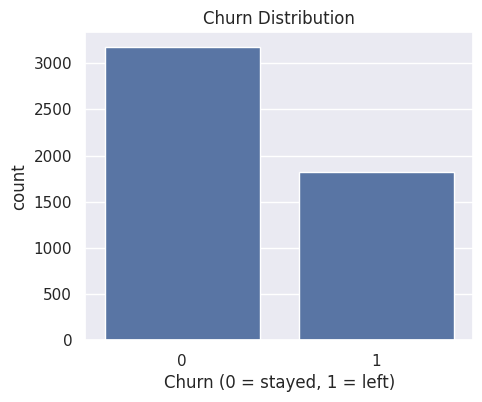

In [5]:
churn_rate = df['churn'].mean()
print(f'Overall churn rate: {churn_rate:.2%}')

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='churn')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = stayed, 1 = left)')
plt.show()

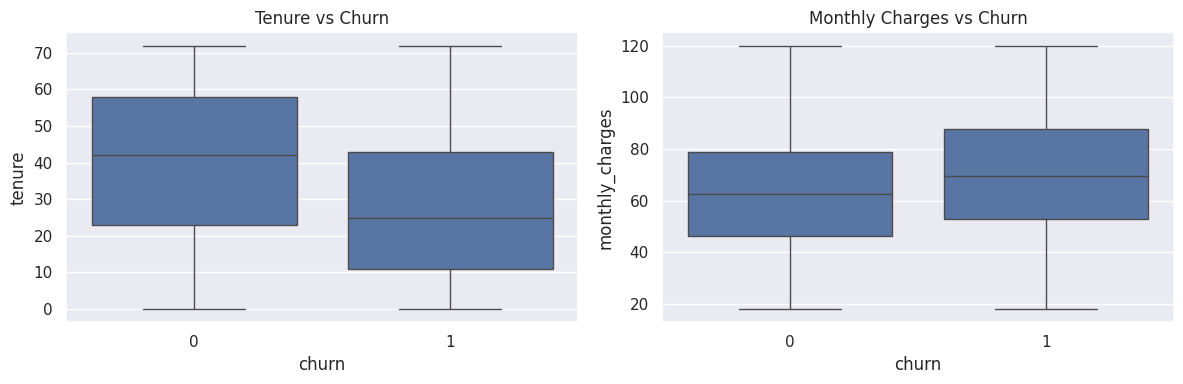

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='churn', y='tenure', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
sns.boxplot(data=df, x='churn', y='monthly_charges', ax=axes[1])
axes[1].set_title('Monthly Charges vs Churn')
plt.tight_layout()
plt.show()

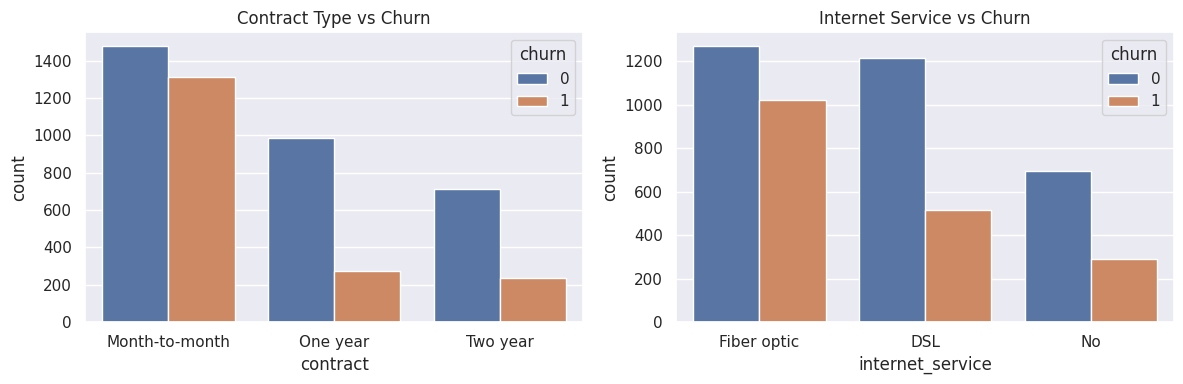

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='contract', hue='churn', ax=axes[0])
axes[0].set_title('Contract Type vs Churn')
sns.countplot(data=df, x='internet_service', hue='churn', ax=axes[1])
axes[1].set_title('Internet Service vs Churn')
plt.tight_layout()
plt.show()

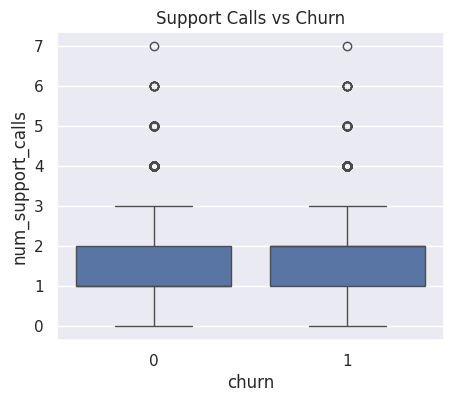

In [8]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df, x='churn', y='num_support_calls')
plt.title('Support Calls vs Churn')
plt.show()